# Colab 01 - PaySim raw EDA (Random Forest track)

**Muc tieu.** EDA co ky luat tren **raw PaySim** (`ealaxi/paysim1`) chay **LOCAL**
(Jupyter / VS Code, khong dung package `pit_fintech`). Day la buoc dau cua quy trinh
**data-centric AI** cho bai toan **fraud detection**, model xuyen suot la **Random Forest**.
Chi can tro `PAYSIM_CSV` toi file CSV tren o cung o cell Setup.

Bo 5 notebook:
1. **01 - EDA** (notebook nay)
2. 02 - Feature engineering + selection (ablation)
3. 03 - Walk-forward CV (Random Forest)
4. 04 - Hyperparameter tuning + chon nguong
5. 05 - Danh gia TEST + SHAP report

> **Nguyen tac vang (giu nguyen tu repo goc):**
> - Khong dung nhan (`isFraud`), `isFlaggedFraud`, hay **4 cot so du** lam dac trung -> ro ri.
> - Metric chinh la **PR-AUC** (khong phai accuracy) vi fraud rat hiem.
> - Split theo **thoi gian** (`step`), khong bao gio split ngau nhien.


## Setup

In [1]:
# === Setup deps (chay LOCAL: Jupyter / VS Code) ==========================
# Chay 1 lan. Hoac cai san trong terminal cua moi truong (venv/conda):
#   pip install duckdb pandas numpy scikit-learn matplotlib
%pip install duckdb pandas numpy scikit-learn matplotlib
print("deps ready")

Note: you may need to restart the kernel to use updated packages.
deps ready


C:\workspace\pit-fintech\.venv\Scripts\python.exe: No module named pip


In [2]:
# === Import data (chay LOCAL): tro thang toi file PaySim CSV tren may =====
# Khong mount Drive, khong upload - chi tro toi file CSV co san tren o cung.
from pathlib import Path

# <<< SUA duong dan CSV cho dung may ban (raw-string r"..." tren Windows) >>>
PAYSIM_CSV = r"C:\workspace\pit-fintech\data\raw\PS_20174392719_1491204439457_log.csv"

# Cache dat canh notebook -> GIU LAI giua cac lan chay (nb02 build, nb03..05 nap lai nhanh).
CACHE_DIR = "_cache"
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

# Fallback: tu do file .csv cung thu muc neu duong dan tren sai.
if not Path(PAYSIM_CSV).exists():
    par = Path(PAYSIM_CSV).parent
    hits = sorted(par.glob("*.csv")) if par.exists() else []
    if hits:
        PAYSIM_CSV = str(hits[0])
        print("Da tu do thay CSV:", PAYSIM_CSV)
    else:
        print("!! Chua thay CSV. Hay sua PAYSIM_CSV cho dung.")

print("PAYSIM_CSV =", PAYSIM_CSV, "| exists:", Path(PAYSIM_CSV).exists())

PAYSIM_CSV = C:\workspace\pit-fintech\data\raw\PS_20174392719_1491204439457_log.csv | exists: True


In [3]:
# === PIT-safe feature module (self-contained, khop hop dong v3 cua repo) ==
# Xay dung dac trung POINT-IN-TIME CORRECT truc tiep tren raw CSV bang DuckDB:
# voi moi giao dich "cutoff", chi doc cac su kien TRUOC do cua CUNG mot nguoi
# nhan (nameDest) trong cac cua so 1h / 24h / 168h. Khong doc so du tai khoan,
# khong doc nhan, khong doc tuong lai -> khong ro ri (leakage).
#
# Pham vi cham diem: type in (CASH_OUT, TRANSFER) va nguoi nhan la KHACH HANG
# (nameDest bat dau bang 'C'). Day dung la noi gian lan PaySim ton tai.
import duckdb
import numpy as np
import pandas as pd

MAX_WINDOW = 168  # cua so lich su rong nhat (gio)

# 2 dac trung request-time + 8 dac trung lich su PIT = 10 (bo v3, ADR-011).
STATIC_FEATURES = ["current_amount", "transaction_type_transfer"]
HISTORY_FEATURES = [
    "pit_prior_count_1h",
    "pit_prior_amount_1h",
    "pit_prior_count_24h",
    "pit_prior_amount_24h",
    "pit_prior_amount_168h",
    "pit_distinct_senders_24h",
    "pit_distinct_senders_168h",
    "pit_steps_since_last_event",
]
ALL_FEATURES = STATIC_FEATURES + HISTORY_FEATURES

# Bo dac trung "deployable" mac dinh (fallback neu chua chay ablation o nb02).
DEPLOYABLE_CORE = [
    "current_amount",
    "transaction_type_transfer",
    "pit_prior_amount_1h",
    "pit_prior_amount_24h",
    "pit_prior_amount_168h",
    "pit_prior_count_1h",
    "pit_prior_count_24h",
]

# 4 cot so du + nhan: TUYET DOI khong duoc lam dac trung dau vao (leakage/label).
FORBIDDEN_INPUTS = [
    "isFraud",
    "isFlaggedFraud",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

# Ranh gioi split theo thoi gian (step). Fit qua khu -> chon nguong tren val ->
# bao cao 1 lan tren test. Split ngau nhien se ro ri tuong lai.
TRAIN_MAX_STEP = 520
VAL_MAX_STEP = 631

# Walk-forward CV: train step <= cut - embargo, test cua so (cut, cut + width].
DEFAULT_CUTS = (360, 420, 480, 540)
DEFAULT_TEST_WIDTH = 55

SEED = 20_260_727

# MAX_STEPS: dat 1 so nho (vd 200) de chay thu nhanh; None = dung toan bo du lieu.
MAX_STEPS = None


def connect_paysim(csv_path, max_steps=None):
    """Doc CSV bang pandas (bo qua dong hong) roi register vao DuckDB lam view `paysim`.

    Doc bang pandas chiu loi tot hon read_csv_auto cua DuckDB (dong hong -> skip thay vi crash).
    source_row_number = thu tu dong trong file, dung lam tie-break cho PIT.
    """
    df = pd.read_csv(csv_path, on_bad_lines="skip")
    df.insert(0, "source_row_number", range(1, len(df) + 1))
    if max_steps:
        df = df[df["step"] <= int(max_steps)].reset_index(drop=True)
    con = duckdb.connect()
    con.register("paysim", df)
    return con


def pit_feature_sql(relation="paysim"):
    """SQL sinh 1 vector dac trung PIT cho moi cutoff trong pham vi cham diem.

    Self-join theo nameDest, chi lay su kien co s.step trong [c.step-168, c.step-1]
    (chan tren la c.step-1 -> loai het su kien cung step). Moi cua so con lai duoc
    thu hep them bang FILTER. Tien duoc cong o DECIMAL(18,2) de tong on dinh.
    """
    return f"""
    SELECT
        c.nameDest AS destination_entity_id,
        c.source_row_number,
        c.step,
        CAST(c.amount AS DOUBLE) AS current_amount,
        (CASE WHEN c.type = 'TRANSFER' THEN 1.0 ELSE 0.0 END) AS transaction_type_transfer,
        (count(s.source_row_number)
            FILTER (WHERE s.step >= c.step - 1   AND s.step <= c.step - 1))::BIGINT
            AS pit_prior_count_1h,
        coalesce(sum(CAST(s.amount AS DECIMAL(18,2)))
            FILTER (WHERE s.step >= c.step - 1   AND s.step <= c.step - 1), 0.0)::DOUBLE
            AS pit_prior_amount_1h,
        (count(s.source_row_number)
            FILTER (WHERE s.step >= c.step - 24  AND s.step <= c.step - 1))::BIGINT
            AS pit_prior_count_24h,
        coalesce(sum(CAST(s.amount AS DECIMAL(18,2)))
            FILTER (WHERE s.step >= c.step - 24  AND s.step <= c.step - 1), 0.0)::DOUBLE
            AS pit_prior_amount_24h,
        coalesce(sum(CAST(s.amount AS DECIMAL(18,2)))
            FILTER (WHERE s.step >= c.step - 168 AND s.step <= c.step - 1), 0.0)::DOUBLE
            AS pit_prior_amount_168h,
        (count(DISTINCT s.nameOrig)
            FILTER (WHERE s.step >= c.step - 24  AND s.step <= c.step - 1))::BIGINT
            AS pit_distinct_senders_24h,
        (count(DISTINCT s.nameOrig)
            FILTER (WHERE s.step >= c.step - 168 AND s.step <= c.step - 1))::BIGINT
            AS pit_distinct_senders_168h,
        coalesce(
            c.step - (max(s.step) FILTER (WHERE s.step >= c.step - 168 AND s.step <= c.step - 1)),
            999
        )::BIGINT AS pit_steps_since_last_event,
        c.isFraud
    FROM {relation} AS c
    LEFT JOIN {relation} AS s
        ON s.nameDest = c.nameDest
        AND s.step >= c.step - {MAX_WINDOW}
        AND s.step <= c.step - 1
    WHERE c.type IN ('CASH_OUT', 'TRANSFER')
      AND starts_with(c.nameDest, 'C')
    GROUP BY c.nameDest, c.source_row_number, c.step, c.type, c.amount, c.isFraud
    ORDER BY c.step, c.source_row_number
    """


def build_modeling_frame(csv_path=None, max_steps=None, cache_path=None, rebuild=False):
    """Tra ve DataFrame: 10 dac trung + step + isFraud (+ id). Cache ra parquet neu co."""
    if cache_path and (not rebuild) and Path(cache_path).exists():
        print("Nap frame tu cache:", cache_path)
        frame = pd.read_parquet(cache_path)
    else:
        con = connect_paysim(csv_path, max_steps=max_steps)
        print("Dang dung lai dac trung PIT (self-join tren raw CSV)... co the mat vai phut.")
        frame = con.execute(pit_feature_sql("paysim")).df()
        con.close()
        if cache_path:
            frame.to_parquet(cache_path, index=False)
            print("Da cache frame ->", cache_path)
    frame[ALL_FEATURES] = frame[ALL_FEATURES].astype("float64")
    frame["isFraud"] = frame["isFraud"].astype(int)
    return frame


def three_way_temporal_split(frame, train_max=TRAIN_MAX_STEP, val_max=VAL_MAX_STEP):
    """train step<=train_max / val (train_max, val_max] / test step>val_max."""
    return {
        "train": frame[frame["step"] <= train_max],
        "val": frame[(frame["step"] > train_max) & (frame["step"] <= val_max)],
        "test": frame[frame["step"] > val_max],
    }


def walk_forward_folds(frame, cuts=DEFAULT_CUTS, test_width=DEFAULT_TEST_WIDTH, embargo=0):
    """Danh sach fold walk-forward theo step; moi phan tu la (cut, train_df, test_df)."""
    folds = []
    for cut in cuts:
        train = frame[frame["step"] <= cut - embargo]
        test = frame[(frame["step"] > cut) & (frame["step"] <= cut + test_width)]
        usable = len(train) > 0 and len(test) > 0 and test["isFraud"].nunique() == 2
        folds.append(
            {"cut": cut, "embargo": embargo, "train": train, "test": test, "usable": usable}
        )
    return folds


print("Feature module loaded. ALL_FEATURES =", ALL_FEATURES)

Feature module loaded. ALL_FEATURES = ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_count_24h', 'pit_prior_amount_24h', 'pit_prior_amount_168h', 'pit_distinct_senders_24h', 'pit_distinct_senders_168h', 'pit_steps_since_last_event']


In [4]:
RAW_COLS = {
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
}

# 1) TRAINING feature: dua thang vao model (deu la CREATED tu raw)
training = ALL_FEATURES  # 2 request-time + 8 PIT history

# 2) DOMAIN feature: lo logic point-in-time, KHONG dua vao model
#    (cutoff / event time / knowledge time / tie-break / entity key)
domain = ["step", "knowledge_step", "source_row_number", "destination_entity_id"]


def origin(col):
    # current_amount ~ amount, transaction_type_transfer ~ type, step la raw...
    base = col.replace("current_amount", "amount")
    return "raw" if col in RAW_COLS or col == "step" else "created"


rows = [{"nhom": "TRAINING", "cot": c, "nguon": origin(c)} for c in training] + [
    {"nhom": "DOMAIN", "cot": c, "nguon": origin(c)} for c in domain
]

print("TRAINING feature (vao model):", len(training), "->", training)
print("DOMAIN feature (PIT logic)  :", domain)
pd.DataFrame(rows)

TRAINING feature (vao model): 10 -> ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_count_24h', 'pit_prior_amount_24h', 'pit_prior_amount_168h', 'pit_distinct_senders_24h', 'pit_distinct_senders_168h', 'pit_steps_since_last_event']
DOMAIN feature (PIT logic)  : ['step', 'knowledge_step', 'source_row_number', 'destination_entity_id']


,nhom,cot,nguon
0,TRAINING,current_amount,created
1,TRAINING,transaction_type_transfer,created
2,TRAINING,pit_prior_count_1h,created
3,TRAINING,pit_prior_amount_1h,created
4,TRAINING,pit_prior_count_24h,created
5,TRAINING,pit_prior_amount_24h,created
6,TRAINING,pit_prior_amount_168h,created
7,TRAINING,pit_distinct_senders_24h,created
8,TRAINING,pit_distinct_senders_168h,created
9,TRAINING,pit_steps_since_last_event,created


## Step 1 - Data understanding

Kich thuoc, dtypes, y nghia tung cot, va cot nao **bi cam** lam dau vao model.


In [5]:
con = connect_paysim(PAYSIM_CSV, max_steps=MAX_STEPS)
shape = con.execute("SELECT count(*) AS rows FROM paysim").df()
print("So dong:", int(shape.loc[0, "rows"]))
con.execute("SELECT * FROM paysim LIMIT 5").df()

So dong: 6362620


,source_row_number,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,2,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,3,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,4,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,5,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### Vai tro tung cot (doc ky)

| Cot | Vai tro |
|---|---|
| `step` | Moc thoi gian (gio thu n cua mo phong) - dung de split & tinh cua so lich su |
| `type` | Loai giao dich (chi CASH_OUT/TRANSFER moi co fraud) |
| `amount` | So tien - dac trung request-time hop le |
| `nameOrig`, `nameDest` | Tai khoan gui / nhan (thuc the) |
| `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` | **BI CAM** - so du, ro ri |
| `isFlaggedFraud` | **BI CAM** - dau ra chinh sach cu |
| `isFraud` | **NHAN (target)** - khong bao gio la dau vao |


In [6]:
roles = []
for c in [
    "step",
    "type",
    "amount",
    "nameOrig",
    "nameDest",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    "isFraud",
]:
    if c in FORBIDDEN_INPUTS and c != "isFraud":
        r = "BI CAM (leakage)"
    elif c == "isFraud":
        r = "NHAN (target) - cam dung lam input"
    else:
        r = "cho phep"
    roles.append({"column": c, "role": r})
import pandas as pd

pd.DataFrame(roles)

,column,role
0,step,cho phep
1,type,cho phep
2,amount,cho phep
3,nameOrig,cho phep
4,nameDest,cho phep
5,oldbalanceOrg,BI CAM (leakage)
6,newbalanceOrig,BI CAM (leakage)
7,oldbalanceDest,BI CAM (leakage)
8,newbalanceDest,BI CAM (leakage)
9,isFlaggedFraud,BI CAM (leakage)


## Step 2 - Data quality (missing, duplicate, outlier)

In [7]:
cols = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
]
null_sql = ", ".join(f"count_if({c} IS NULL) AS {c}_nulls" for c in cols)
display(con.execute(f"SELECT {null_sql} FROM paysim").df().T.rename(columns={0: "nulls"}))

,nulls
step_nulls,0.0
type_nulls,0.0
amount_nulls,0.0
nameOrig_nulls,0.0
oldbalanceOrg_nulls,0.0
newbalanceOrig_nulls,0.0
nameDest_nulls,0.0
oldbalanceDest_nulls,0.0
newbalanceDest_nulls,0.0
isFraud_nulls,0.0


In [8]:
# Outlier amount: global + theo type (duoi phai rat nang la binh thuong voi tien).
con.execute("""
    SELECT type,
           count(*) AS rows,
           round(avg(amount), 2) AS mean_amount,
           round(quantile_cont(amount, 0.50), 2) AS p50,
           round(quantile_cont(amount, 0.99), 2) AS p99,
           round(max(amount), 2) AS max_amount
    FROM paysim GROUP BY type ORDER BY rows DESC
""").df()

,type,rows,mean_amount,p50,p99,max_amount
0,CASH_OUT,2237500,176273.96,147072.19,579654.07,10000000.00
1,PAYMENT,2151495,13057.60,9482.19,59500.11,238637.98
2,CASH_IN,1399284,168920.24,143427.71,550870.86,1915267.90
3,TRANSFER,532909,910647.01,486308.39,10000000.00,92445516.64
4,DEBIT,41432,5483.67,3048.99,50817.98,569077.51


## Step 3 - Univariate

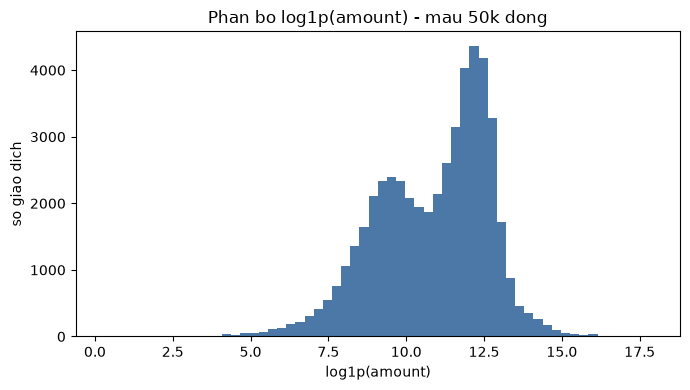

In [9]:
import matplotlib.pyplot as plt

amt = (
    con.execute("""
    SELECT amount FROM paysim USING SAMPLE 50000 ROWS
""")
    .df()["amount"]
    .to_numpy()
)
plt.figure(figsize=(7, 4))
plt.hist(np.log1p(amt), bins=60, color="#4C78A8")
plt.title("Phan bo log1p(amount) - mau 50k dong")
plt.xlabel("log1p(amount)")
plt.ylabel("so giao dich")
plt.tight_layout()
plt.show()

In [10]:
con.execute("SELECT type, count(*) AS rows FROM paysim GROUP BY type ORDER BY rows DESC").df()

,type,rows
0,CASH_OUT,2237500
1,PAYMENT,2151495
2,CASH_IN,1399284
3,TRANSFER,532909
4,DEBIT,41432


## Step 4 - Bivariate: fraud song o dau?

In [11]:
# Fraud CHI ton tai trong TRANSFER va CASH_OUT.
fbt = con.execute("""
    SELECT type,
           count(*) AS rows,
           sum(isFraud) AS frauds,
           round(100.0 * sum(isFraud) / count(*), 4) AS fraud_rate_pct
    FROM paysim GROUP BY type ORDER BY frauds DESC
""").df()
display(fbt)

,type,rows,frauds,fraud_rate_pct
0,CASH_OUT,2237500,4116.0,0.1840
1,TRANSFER,532909,4097.0,0.7688
2,CASH_IN,1399284,0.0,0.0000
3,PAYMENT,2151495,0.0,0.0000
4,DEBIT,41432,0.0,0.0000


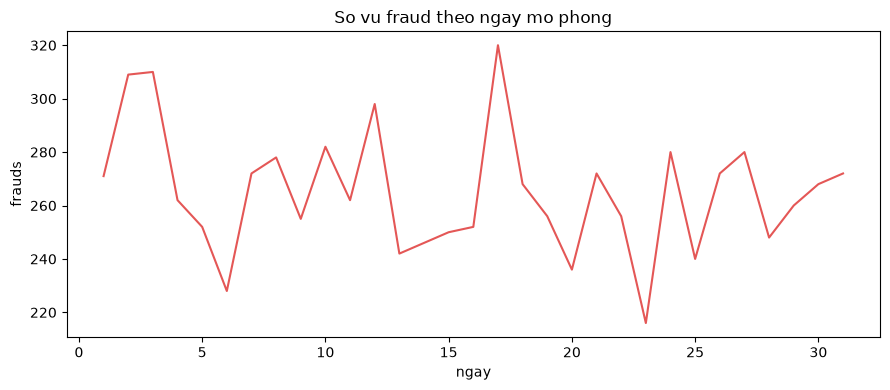

In [12]:
# Fraud theo "ngay" mo phong (step la gio -> 24 gio = 1 ngay).
daily = con.execute("""
    SELECT (floor((step - 1) / 24) + 1)::INTEGER AS sim_day,
           count(*) AS rows,
           sum(isFraud) AS frauds
    FROM paysim GROUP BY sim_day ORDER BY sim_day
""").df()
plt.figure(figsize=(9, 4))
plt.plot(daily["sim_day"], daily["frauds"], color="#E45756")
plt.title("So vu fraud theo ngay mo phong")
plt.xlabel("ngay")
plt.ylabel("frauds")
plt.tight_layout()
plt.show()

### Leakage demo - vi sao 4 cot so du bi cam

Voi giao dich gian lan, so du thuong bi rut ve 0 (`newbalanceOrig == 0`). Model se
"hoc vet" dau nay -> AUC gia cao nhung khong dung duoc khi trien khai (so du cuoi chi
biet SAU khi giao dich xay ra = tuong lai).


In [13]:
con.execute("""
    SELECT isFraud,
           count(*) AS rows,
           round(avg(CASE WHEN newbalanceOrig = 0 THEN 1.0 ELSE 0.0 END), 4) AS share_newbal_orig_zero
    FROM paysim
    WHERE type IN ('TRANSFER','CASH_OUT')
    GROUP BY isFraud ORDER BY isFraud
""").df()

,isFraud,rows,share_newbal_orig_zero
0,0,2762196,0.9010
1,1,8213,0.9805


In [14]:
# === Ti le fraud tren TOAN BO du lieu ====================================
_con = connect_paysim(PAYSIM_CSV)  # toan bo, khong gioi han MAX_STEPS
overall = _con.execute("""
    SELECT count(*)                              AS total_rows,
           sum(isFraud)                          AS frauds,
           round(100.0 * sum(isFraud)/count(*), 4) AS fraud_rate_pct,
           round(count(*)::DOUBLE / sum(isFraud), 1) AS one_fraud_per_n_rows
    FROM paysim
""").df()
_con.close()

r = overall.iloc[0]
print(f"Tong giao dich : {int(r.total_rows):,}")
print(f"So vu fraud    : {int(r.frauds):,}")
print(f"Ti le fraud    : {r.fraud_rate_pct}%  (~1 fraud / {r.one_fraud_per_n_rows:.0f} giao dich)")
print("=> Cuc ky mat can bang -> vi sao metric chinh la PR-AUC, khong phai accuracy.")
overall

Tong giao dich : 6,362,620
So vu fraud    : 8,213
Ti le fraud    : 0.1291%  (~1 fraud / 775 giao dich)
=> Cuc ky mat can bang -> vi sao metric chinh la PR-AUC, khong phai accuracy.


,total_rows,frauds,fraud_rate_pct,one_fraud_per_n_rows
0,6362620,8213.0,0.1291,774.7


## MLflow logging (Data-Centric AI)

Ba cell cuoi (chay sau cung, sau khi da chay het notebook): **schema chuan** (giong het moi notebook) + **cell log** rieng cua notebook nay. Log len MLflow chung `http://100.116.36.6:5000`; khong toi duoc thi fallback `./mlruns`.

In [ ]:
# ============================================================================
# MLflow logging schema - Data-Centric AI (Andrew Ng). CELL CHUAN, dat O CUOI
# notebook. Copy-paste GIONG HET vao ca 5 notebook colab_01..05.
# Log len MLflow chung (http://100.116.36.6:5000); server khong toi duoc ->
# fallback local ./mlruns. Chua cai mlflow -> notebook van chay, chi khong log.
# ============================================================================
import hashlib
import json as _json
import os
import socket
from datetime import datetime, timezone
from pathlib import Path as _Path

MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://100.116.36.6:5000")
MLFLOW_EXPERIMENT = "paysim-fraud-rf-colab"      # tach khoi track LightGBM cua src/
MLFLOW_LOCAL_FALLBACK = "file:./mlruns"           # dung khi server chung down
REGISTRY_MODEL_NAME = "paysim-fraud-rf"           # CHI nb05 register (RF experimental)


def _mlflow_ready():
    try:
        import mlflow
        import mlflow.sklearn  # noqa: F401
    except ImportError:
        print("[mlflow] chua cai (pip install mlflow) -> notebook van chay, khong log")
        return None
    uri = MLFLOW_TRACKING_URI
    try:  # ping nhanh 2s; server chung khong toi duoc -> fallback local
        netloc = uri.split("//", 1)[-1].split("/", 1)[0]
        host, _, port = netloc.partition(":")
        socket.create_connection((host, int(port or 80)), timeout=2).close()
    except OSError:
        print("[mlflow] %s khong toi duoc -> fallback %s" % (uri, MLFLOW_LOCAL_FALLBACK))
        uri = MLFLOW_LOCAL_FALLBACK
    mlflow.set_tracking_uri(uri)
    mlflow.set_experiment(MLFLOW_EXPERIMENT)
    print("[mlflow] tracking=%s experiment=%s" % (uri, MLFLOW_EXPERIMENT))
    return mlflow


MLFLOW = _mlflow_ready()   # None => moi helper duoi day tu no-op


def data_version(frame=None, csv_path=None):
    """Danh tinh du lieu (Data-Centric): hash prefix CSV + so dong + range step + fraud rate."""
    info = {}
    p = csv_path or globals().get("PAYSIM_CSV")
    if p and _Path(p).exists():
        h = hashlib.sha256()
        with open(p, "rb") as f:
            h.update(f.read(8 * 1024 * 1024))   # 8MB dau -> dinh danh nhanh, on dinh
        info["csv_sha8"] = h.hexdigest()[:8]
        info["csv_bytes"] = _Path(p).stat().st_size
    info["max_steps"] = str(globals().get("MAX_STEPS"))
    if frame is not None and len(frame):
        info["row_count"] = int(len(frame))
        info["step_min"] = int(frame["step"].min())
        info["step_max"] = int(frame["step"].max())
        info["fraud_rate"] = round(float(frame["isFraud"].mean()), 6)
    return info


def start_run(stage, params=None, extra_tags=None):
    if MLFLOW is None:
        return None
    run = MLFLOW.start_run(run_name="%s__%s" % (stage, datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")))
    tags = {"stage": stage, "model_family": "random_forest", "code_source": "colab",
            "primary_metric": "pr_auc", "split_protocol": "temporal_70_15_15",
            "sealed_test_touched": "false"}
    tags.update(extra_tags or {})
    MLFLOW.set_tags(tags)
    if params:
        MLFLOW.log_params({k: v for k, v in params.items() if v is not None})
    return run


def log_metrics(metrics):
    if MLFLOW is None:
        return
    MLFLOW.log_metrics({k: float(v) for k, v in metrics.items() if v is not None})


def log_sliced_pr_auc(y_true, y_score, slices, prefix="pr_auc"):
    """slices = {ten: mask_bool}. Chi log slice co ca 2 lop de PR-AUC co nghia (Data-Centric)."""
    if MLFLOW is None:
        return
    import numpy as np
    from sklearn.metrics import average_precision_score
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    MLFLOW.log_metric(prefix, float(average_precision_score(y_true, y_score)))
    for name, mask in slices.items():
        mask = np.asarray(mask, dtype=bool)
        if mask.sum() and 0 < int(y_true[mask].sum()) < int(mask.sum()):
            MLFLOW.log_metric("%s__%s" % (prefix, name),
                              float(average_precision_score(y_true[mask], y_score[mask])))


def log_json_artifact(obj, filename):
    if MLFLOW is None:
        return
    p = _Path(filename)
    p.write_text(_json.dumps(obj, indent=2, default=str), encoding="utf-8")
    MLFLOW.log_artifact(str(p))


def log_file_artifact(path):
    if MLFLOW is None or not _Path(path).exists():
        return
    MLFLOW.log_artifact(str(path))


def log_error_samples(frame, features, y_true, y_pred, y_score, n=300, filename="error_samples.csv"):
    """Data-Centric error analysis: xuat cac ca sai (FN/FP) de soi lai chat luong du lieu."""
    if MLFLOW is None:
        return
    import numpy as np
    err = frame[list(features)].copy()
    for col in ("destination_entity_id", "step"):
        if col in frame:
            err[col] = frame[col].to_numpy()
    err["y_true"] = np.asarray(y_true)
    err["y_pred"] = np.asarray(y_pred)
    err["y_score"] = np.asarray(y_score)
    err = err[err["y_true"] != err["y_pred"]].sort_values("y_score", ascending=False).head(n)
    p = _Path(filename)
    err.to_csv(p, index=False)
    MLFLOW.log_artifact(str(p))
    print("[mlflow] error_samples: %d ca sai -> %s" % (len(err), filename))


def log_sklearn_model(model, register=False, artifact_path="model"):
    """Log RF; register=True -> tao model version tren Model Registry (chi nb05)."""
    if MLFLOW is None:
        return None
    name = REGISTRY_MODEL_NAME if register else None
    try:  # mlflow >=2.20/3 dung name=; ban cu dung artifact_path=
        info = MLFLOW.sklearn.log_model(model, name=artifact_path, registered_model_name=name)
    except TypeError:
        info = MLFLOW.sklearn.log_model(model, artifact_path=artifact_path, registered_model_name=name)
    if register:
        print("[mlflow] registered '%s' <- %s" % (REGISTRY_MODEL_NAME, getattr(info, "model_uri", "?")))
    return info


def log_rf_evaluation(stage, model, y_true, y_pred, features=None, y_score=None,
                      threshold=0.5, params=None, extra_tags=None, register=False):
    """Log 1 danh gia RF DAY DU cho MLflow (truc quan hon confusion don thuan):
    confusion tn/fp/fn/tp + precision/recall/f1/accuracy + pr_auc/roc_auc (neu co y_score)
    + threshold + feature gain (feature_importances_). register=True -> dang ky model."""
    if MLFLOW is None:
        print("[mlflow] skipped RF evaluation: tracking unavailable")
        return None
    import numpy as np
    from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                                 precision_score, recall_score)

    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics = {"confusion_tn": int(tn), "confusion_fp": int(fp),
               "confusion_fn": int(fn), "confusion_tp": int(tp),
               "precision": precision_score(y_true, y_pred, zero_division=0),
               "recall": recall_score(y_true, y_pred, zero_division=0),
               "f1": f1_score(y_true, y_pred, zero_division=0),
               "accuracy": accuracy_score(y_true, y_pred)}
    if y_score is not None and 0 < int(y_true.sum()) < len(y_true):
        from sklearn.metrics import average_precision_score, roc_auc_score
        y_score = np.asarray(y_score, dtype=float)
        metrics["pr_auc"] = average_precision_score(y_true, y_score)
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    gain = {}
    imp = getattr(model, "feature_importances_", None)
    if imp is not None and features is not None and len(features) == len(imp):
        gain = {str(f): float(g) for f, g in zip(features, imp)}
    run_params = {"threshold": float(threshold), "n_rows_evaluated": int(len(y_true)),
                  "n_features": int(getattr(model, "n_features_in_", len(features or []))),
                  "rf_n_estimators": int(model.get_params().get("n_estimators", 0)),
                  "rf_max_depth": model.get_params().get("max_depth"),
                  "rf_max_samples": model.get_params().get("max_samples"),
                  "rf_min_samples_leaf": model.get_params().get("min_samples_leaf"),
                  "rf_random_state": model.get_params().get("random_state")}
    run_params.update(params or {})
    tags = {"stage": stage, "model_family": "random_forest",
            "metric_contract": "full_eval", "code_source": "colab",
            "sealed_test_touched": "false"}
    tags.update(extra_tags or {})
    artifact = {"labels": [0, 1], "threshold": float(threshold),
                "matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
                "metrics": {k: float(v) for k, v in metrics.items()},
                "feature_gain": dict(sorted(gain.items(), key=lambda kv: kv[1], reverse=True))}
    with MLFLOW.start_run(run_name="rf__%s" % stage):
        MLFLOW.set_tags(tags)
        MLFLOW.log_params({k: v for k, v in run_params.items() if v is not None})
        MLFLOW.log_metrics({k: float(v) for k, v in metrics.items()})
        if gain:
            MLFLOW.log_metrics({"gain__%s" % f: g for f, g in gain.items()})
        log_json_artifact(artifact, "evaluation_%s.json" % stage)
        log_sklearn_model(model, register=register, artifact_path="model")
        run_id = MLFLOW.active_run().info.run_id
    _msg = "P=%.3f R=%.3f F1=%.3f" % (metrics["precision"], metrics["recall"], metrics["f1"])
    if "pr_auc" in metrics:
        _msg += " PR-AUC=%.4f" % metrics["pr_auc"]
    print("[mlflow] RF eval logged stage=%s run=%s %s" % (stage, run_id, _msg))
    return {**metrics, "run_id": run_id}


def end_run():
    if MLFLOW is not None:
        MLFLOW.end_run()


In [16]:
# --- MLflow: log DATA PROFILE (Data-Centric, khong train model) --------------
if MLFLOW is not None:
    _c = connect_paysim(PAYSIM_CSV)                      # toan bo de profile that
    _prof = _c.execute("SELECT step, isFraud FROM paysim").df()
    _by_type = _c.execute(
        "SELECT type, count(*) AS n_rows, sum(isFraud) AS n_frauds FROM paysim GROUP BY type"
    ).df()
    _c.close()
    _dv = data_version(_prof, PAYSIM_CSV)
    start_run("eda", params=_dv)
    log_metrics({"total_rows": len(_prof), "total_frauds": int(_prof["isFraud"].sum()),
                 "fraud_rate": float(_prof["isFraud"].mean())})
    log_json_artifact({"data_version": _dv,
                       "by_type": _by_type.to_dict(orient="records"),
                       "forbidden_inputs": FORBIDDEN_INPUTS}, "data_profile.json")
    end_run()
    print("EDA data-profile da log len MLflow.")


🏃 View run eda__20260824-050634 at: http://100.116.36.6:5000/#/experiments/2/runs/2e586551c74b4b4b8cb82fd2f89c510e
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/2
EDA data-profile da log len MLflow.
